In [1]:
import qiskit
from qiskit import QuantumCircuit, QuantumRegister
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFTGate
from qiskit import transpile
from qiskit.visualization import plot_histogram
from PIL import Image
import numpy as np

import matplotlib.pyplot as plt

In [2]:
def encode_image(filename, n_qubits):
    #open image file in greyscale and form normalized array
    im = Image.open(filename,'r')
    im = im.convert("L")
    pixel_value_array = np.array(im.get_flattened_data())
    
    #Normalize the pixel values
    norm = np.linalg.norm(pixel_value_array)
    norm_array = pixel_value_array/norm


    #translate normalized array into qubits
    
    qc = QuantumCircuit(n_qubits)
    qc.initialize(norm_array, qc.qubits)
    return qc,norm_array
    

In [12]:
def measure_image(qc, n_qubits):
    shots = 200000
    qc.measure_all()
    aer_sim = AerSimulator()
    decomposed_qc = qc.decompose() 
    t_qc = transpile(decomposed_qc, aer_sim)
    result = aer_sim.run(t_qc,shots=shots).result()
    counts = result.get_counts()

    #construct measured image
    measured_arr = np.zeros(2**n_qubits,dtype=float)
    bin_var = 0b0000
    dict_keys = counts.keys()
    for i in range(2**n_qubits):
        #generate str representation of each state
        str_var = bin(bin_var)[2:]
        str_var = str_var.zfill(n_qubits)
        #if in counts, fill array with avg value
        if str_var in dict_keys:
            measured_arr[i] = counts[f'{str_var}']/shots
            #take sqrt to convert probability to the amplitude
            measured_arr[i] = np.sqrt(measured_arr[i])
        else:
            measured_arr[i] = 0
        bin_var += 1

    #convert back into RGB
    measured_arr = measured_arr * 255
    size = int(np.sqrt(2**n_qubits))
    measured_arr = measured_arr.reshape((size, size))
    return measured_arr
    
    

C:\Users\benz5\AppData\Local\Temp\ipykernel_47120\2826756985.py:8: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(shifted_image))


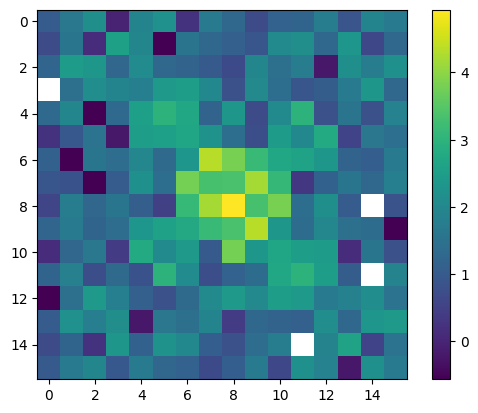

In [13]:
#QFT on image
qc,norm_arr = encode_image('circle.png', 8)

qc.append(QFTGate(8), qc.qubits)

measured_arr = measure_image(qc, 8)
shifted_image = np.fft.fftshift(measured_arr)
plt.imshow(np.log(shifted_image))
plt.colorbar()

C:\Users\benz5\AppData\Local\Temp\ipykernel_47120\3687604775.py:8: RuntimeWarning: divide by zero encountered in log
  magnitude_spectrum = np.log(np.abs(f_shift))


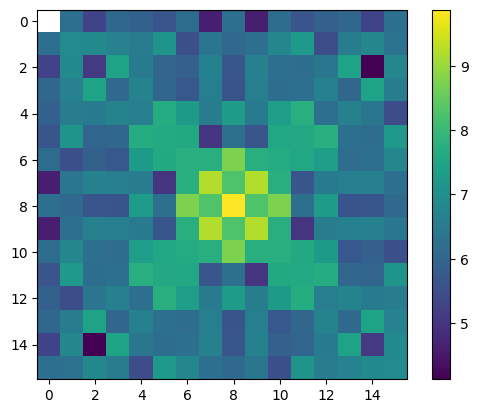

In [11]:
#classical FT
im = Image.open('circle.png','r')
im = im.convert("L")

f_transform = np.fft.fft2(np.asarray(im))

f_shift = np.fft.fftshift(f_transform)
magnitude_spectrum = np.log(np.abs(f_shift))

plt.imshow(magnitude_spectrum)
plt.colorbar()